In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv


/tmp/ipykernel_57/4151358189.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby('Spend_Level')[['Success_Percentage','Sales_m']].mean().reset_index()


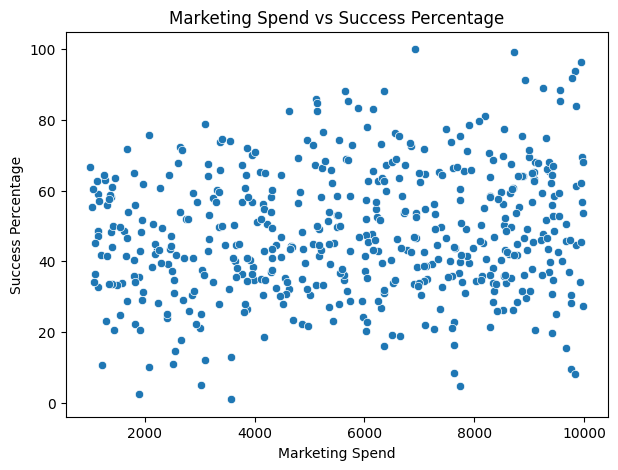

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv")

# Clean
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Create bins
df['Spend_Level'] = pd.qcut(df['M_Spend'], 3, labels=['Low','Medium','High'])

# Create table
table = df.groupby('Spend_Level')[['Success_Percentage','Sales_m']].mean().reset_index()

# Save table
table.to_csv("/kaggle/working/table_RQ1.csv", index=False)

# Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x='M_Spend', y='Success_Percentage', data=df)
plt.title("Marketing Spend vs Success Percentage")
plt.xlabel("Marketing Spend")
plt.ylabel("Success Percentage")

# Save figure
plt.savefig("/kaggle/working/figure_RQ1.pdf")
plt.show()